# Notebook 2 - Stage 2: Base and Sandhangan Classifiers

Trains two EfficientNetB0 classifiers matching the thesis methodology (Bab III Section 3.6).

| Section | Task | Data source | Architecture |
|---------|------|--------------|--------------|
| 2 | Base character recognition | dataset_stage2/base/ | EfficientNetB0 |
| 3 | Unified sandhangan recognition | dataset_stage2/sandhangan/ | EfficientNetB0 |

Classes below MIN_SAMPLES and the unlabeled folder are excluded automatically.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Section 0 - Setup and Configuration

In [ ]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU        : {gpus if gpus else 'None - CPU only'}")

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Paths - adjust for your environment (local or Colab)
BASE_DIR           = r"/content/drive/MyDrive/Dataset Skripsi/dataset_stage2/base"
SANDH_DIR          = r"/content/drive/MyDrive/Dataset Skripsi/dataset_stage2/sandhangan"
MODEL_DIR          = r"/content/drive/MyDrive/Dataset Skripsi/tahap2"

BASE_MODEL_PATH    = os.path.join(MODEL_DIR, "stage2_base.keras")
SANDH_MODEL_PATH   = os.path.join(MODEL_DIR, "stage2_sandhangan.keras")

os.makedirs(MODEL_DIR, exist_ok=True)

# Hyperparameters
IMG_SIZE            = 128
BATCH_SIZE          = 32
EPOCHS              = 60
LR                  = 1e-3
LR_FINETUNE         = 1e-4
FINE_TUNE_AT        = 100   # base classifier: unfreeze backbone from this layer onward
FINE_TUNE_AT_SANDH  = 150   # sandhangan: fewer layers unfrozen due to smaller dataset
VAL_SPLIT           = 0.2
RANDOM_SEED         = 42
MIN_SAMPLES         = 10

print("Configuration loaded")
print(f"  Models -> {os.path.abspath(MODEL_DIR)}")
print(f"  Base   -> {os.path.abspath(BASE_DIR)}")
print(f"  Sandh. -> {os.path.abspath(SANDH_DIR)}")

Configuration loaded
  Models -> /content/drive/MyDrive/Dataset Skripsi/tahap2
  Base   -> /content/drive/MyDrive/Dataset Skripsi/dataset_stage2/base
  Sandh. -> /content/drive/MyDrive/Dataset Skripsi/dataset_stage2/sandhangan


In [ ]:
def get_valid_classes(dataset_dir, min_samples=MIN_SAMPLES):
    all_classes = []
    for cls in sorted(os.listdir(dataset_dir)):
        if cls == "unlabeled":
            continue
        cls_dir = os.path.join(dataset_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        n = len([f for f in os.listdir(cls_dir)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        all_classes.append((cls, n))
    included = [(c, n) for c, n in all_classes if n >= min_samples]
    dropped  = [(c, n) for c, n in all_classes if n < min_samples]
    return [c for c, n in included], included, dropped


def print_inventory(dataset_dir, label, min_samples=MIN_SAMPLES):
    valid, included, dropped = get_valid_classes(dataset_dir, min_samples)
    total_incl = sum(n for _, n in included)
    total_drop = sum(n for _, n in dropped)

    print(f"\n{label}   (MIN_SAMPLES={min_samples})")
    print(f"{'CLASS':<24} {'SAMPLES':>7}  STATUS")
    print("-" * 44)
    for cls, n in included:
        print(f"  {cls:<22} {n:>7}  included")
    for cls, n in dropped:
        print(f"  {cls:<22} {n:>7}  dropped (<{min_samples})")

    ul_dir = os.path.join(dataset_dir, "unlabeled")
    if os.path.isdir(ul_dir):
        ul_n = len([f for f in os.listdir(ul_dir)
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        if ul_n:
            print(f"  {'unlabeled':<22} {ul_n:>7}  excluded")

    print("-" * 44)
    print(f"  Included : {len(included)} classes, {total_incl} samples")
    print(f"  Dropped  : {len(dropped)} classes, {total_drop} samples")
    return valid


def build_generators(dataset_dir, valid_classes,
                     img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                     val_split=VAL_SPLIT, seed=RANDOM_SEED):
    aug = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=8,
        width_shift_range=0.08,
        height_shift_range=0.08,
        zoom_range=0.10,
        shear_range=0.05,
        horizontal_flip=False,
        fill_mode="nearest",
        validation_split=val_split,
    )
    plain = ImageDataGenerator(rescale=1.0 / 255, validation_split=val_split)
    kw = dict(
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode="categorical",
        color_mode="grayscale",
        classes=valid_classes,
        seed=seed,
    )
    train_gen = aug.flow_from_directory(
        dataset_dir, subset="training",   shuffle=True,  **kw)
    val_gen   = plain.flow_from_directory(
        dataset_dir, subset="validation", shuffle=False, **kw)
    return train_gen, val_gen


def build_sandh_generators(dataset_dir, valid_classes,
                            img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                            val_split=VAL_SPLIT, seed=RANDOM_SEED):
    aug = ImageDataGenerator(
        rescale=1.0 / 255,
        rotation_range=15,
        width_shift_range=0.12,
        height_shift_range=0.12,
        zoom_range=0.15,
        shear_range=0.10,
        horizontal_flip=False,
        fill_mode="nearest",
        validation_split=val_split,
    )
    plain = ImageDataGenerator(rescale=1.0 / 255, validation_split=val_split)
    kw = dict(
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode="categorical",
        color_mode="grayscale",
        classes=valid_classes,
        seed=seed,
    )
    train_gen = aug.flow_from_directory(
        dataset_dir, subset="training",   shuffle=True,  **kw)
    val_gen   = plain.flow_from_directory(
        dataset_dir, subset="validation", shuffle=False, **kw)
    return train_gen, val_gen


def build_efficientnet_classifier(num_classes, img_size=IMG_SIZE,
                                   dropout_head=0.35, dropout_dense=0.20):
    inputs   = keras.Input(shape=(img_size, img_size, 1))
    x        = layers.Conv2D(3, 1, padding="same", use_bias=False)(inputs)
    backbone = EfficientNetB0(include_top=False, weights="imagenet",
                               input_shape=(img_size, img_size, 3), pooling="avg")
    backbone.trainable = False
    x   = backbone(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(dropout_head)(x)
    x   = layers.Dense(256, activation="relu")(x)
    x   = layers.Dropout(dropout_dense)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, out), backbone


def get_class_weights(train_gen):
    cw = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(train_gen.num_classes),
        y=train_gen.classes,
    )
    return dict(enumerate(cw))


def standard_callbacks(model_path, monitor="val_accuracy",
                        patience_es=12, patience_lr=5):
    return [
        keras.callbacks.EarlyStopping(
            monitor=monitor, mode="max", patience=patience_es,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor=monitor, mode="max", factor=0.4,
            patience=patience_lr, min_lr=1e-7, verbose=1),
        keras.callbacks.ModelCheckpoint(
            model_path, monitor=monitor, mode="max",
            save_best_only=True, verbose=1),
    ]


def plot_history(h1, h2=None, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for metric, ax in zip(["accuracy", "loss"], axes):
        ep1 = range(1, len(h1.history[metric]) + 1)
        ax.plot(ep1, h1.history[metric],          "b-",  label="Train P1")
        ax.plot(ep1, h1.history[f"val_{metric}"], "b--", label="Val P1")
        if h2:
            offset = len(h1.history[metric])
            ep2 = range(offset + 1, offset + len(h2.history[metric]) + 1)
            ax.plot(ep2, h2.history[metric],          "r-",  label="Train P2")
            ax.plot(ep2, h2.history[f"val_{metric}"], "r--", label="Val P2")
        ax.set_xlabel("Epoch"); ax.set_ylabel(metric.capitalize())
        ax.set_title(f"{metric.capitalize()} - {title}")
        ax.legend()
    plt.tight_layout()
    plt.savefig(f"training_{title.lower().replace(' ', '_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()


def evaluate_and_plot(model, val_gen, title=""):
    val_gen.reset()
    y_prob = model.predict(val_gen, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = val_gen.classes
    names  = list(val_gen.class_indices.keys())

    cm        = confusion_matrix(y_true, y_pred)
    mean_acc  = (y_pred == y_true).mean()
    per_class = cm.diagonal() / cm.sum(axis=1).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(max(11, len(names) * 0.9 + 3), 5))
    annot = len(names) <= 25
    sns.heatmap(cm, annot=annot, fmt="d", cmap="Blues",
                xticklabels=names, yticklabels=names, ax=axes[0],
                annot_kws={"size": 7})
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
    axes[0].set_title(f"Confusion Matrix - {title}")
    axes[0].tick_params(axis="x", rotation=45, labelsize=7)
    axes[0].tick_params(axis="y", rotation=0,  labelsize=7)

    colors = ["#d62728" if a < 0.70 else "#2ca02c" if a >= 0.90 else "#1f77b4"
              for a in per_class]
    axes[1].bar(names, per_class, color=colors)
    axes[1].axhline(mean_acc, color="black", ls="--",
                    label=f"Mean = {mean_acc:.3f}")
    axes[1].set_ylabel("Per-class Accuracy"); axes[1].set_ylim(0, 1.05)
    axes[1].set_title(f"Per-Class Accuracy - {title}")
    axes[1].legend()
    axes[1].tick_params(axis="x", rotation=45, labelsize=7)

    plt.tight_layout()
    plt.savefig(f"eval_{title.lower().replace(' ', '_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(classification_report(y_true, y_pred, target_names=names, digits=4))
    return float(mean_acc)


print("Shared utilities loaded")

Shared utilities loaded


## Seksi 1 - Persiapan Dataset

Cek kelas yang tersedia di kedua folder sebelum mulai training.
Kelas dengan sampel di bawah MIN_SAMPLES dan folder unlabeled otomatis dilewati.

Kelas sandhangan gabungan (wulu_layar, pepet_cecak, pepet_layar) sekarang sudah punya sampel yang cukup
sehingga dilatih sebagai kelas tersendiri, tidak digabung lagi ke kelas induknya.

In [ ]:
# tampilkan daftar kelas dan jumlah sampelnya sebelum training dimulai
base_classes  = print_inventory(BASE_DIR,  "BASE")
sandh_classes = print_inventory(SANDH_DIR, "SANDHANGAN")


BASE   (MIN_SAMPLES=10)
CLASS                    SAMPLES  STATUS
--------------------------------------------
  _ha                         32  included
  _pa                         31  included
  _sa                         42  included
  ba                          34  included
  ca                          40  included
  da                          64  included
  dha                         42  included
  ga                         112  included
  ha                          48  included
  ja                          33  included
  ka                          91  included
  la                          55  included
  ma                          82  included
  na                         181  included
  nga                         64  included
  nya                         36  included
  pa                          68  included
  pada_lingsa                 48  included
  pada_lungsi                 48  included
  ra                          65  included
  sa                         

## Section 2 - Base Classifier

Recognises hanacaraka characters and base-position diacritics (taling, tarung, wignyan).
Auto-filtered to classes with at least MIN_SAMPLES samples.
Architecture: EfficientNetB0 with two-phase transfer learning.

In [ ]:
# 2.0 - Skip guard
if len(base_classes) < 2:
    raise RuntimeError(
        f"Section 2 skipped - only {len(base_classes)} base class(es) meet "
        f"MIN_SAMPLES={MIN_SAMPLES}. Label more data with density_labeler.py --mode stage2.")

# 2.1 - Generators
base_train, base_val = build_generators(BASE_DIR, base_classes)
print(f"\nBase classes ({base_train.num_classes}): {base_classes}")
print(f"Train samples : {base_train.samples}")
print(f"Val   samples : {base_val.samples}")

# 2.2 - Class weights
base_class_weights = get_class_weights(base_train)
print(f"\nClass weights (top-5 heaviest):")
idx_to_cls = {v: k for k, v in base_train.class_indices.items()}
sorted_cw  = sorted(base_class_weights.items(), key=lambda x: x[1], reverse=True)
for idx, w in sorted_cw[:5]:
    print(f"  {idx_to_cls[idx]:<14}  w={w:.3f}")

Found 1340 images belonging to 27 classes.
Found 321 images belonging to 27 classes.

Base classes (27): ['_ha', '_pa', '_sa', 'ba', 'ca', 'da', 'dha', 'ga', 'ha', 'ja', 'ka', 'la', 'ma', 'na', 'nga', 'nya', 'pa', 'pada_lingsa', 'pada_lungsi', 'ra', 'sa', 'ta', 'taling', 'tarung', 'wa', 'wignyan', 'ya']
Train samples : 1340
Val   samples : 321

Class weights (top-5 heaviest):
  _pa             w=1.985
  _ha             w=1.909
  ya              w=1.909
  ja              w=1.838
  ba              w=1.772


In [ ]:
# 2.3 - Build model
base_model, base_bb = build_efficientnet_classifier(base_train.num_classes)
base_model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss="categorical_crossentropy",
    metrics=["accuracy",
             keras.metrics.TopKCategoricalAccuracy(3, name="top3_acc")],
)
base_model.summary(line_length=90)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)              │ (None, 128, 128, 1)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                       │ (None, 128, 128, 3)          │               3 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)           │ (None, 1280)                 │       4,049,571 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization                   │ (None, 1280)                 │           5,120 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout (Dropout)                     │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense (Dense)                         │ (None, 256)                  │         327,936 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                   │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                       │ (None, 27)                   │           6,939 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 4,389,569 (16.74 MB)

 Trainable params: 337,438 (1.29 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# 2.4 - Phase 1: train head only (backbone frozen)
p1_path = BASE_MODEL_PATH.replace(".keras", "_phase1.keras")
print("Phase 1 - head only, backbone frozen")
h_base_p1 = base_model.fit(
    base_train,
    validation_data=base_val,
    epochs=EPOCHS,
    class_weight=base_class_weights,
    callbacks=standard_callbacks(p1_path),
)
print(f"Phase 1 best val_accuracy: {max(h_base_p1.history['val_accuracy']):.4f}")

Phase 1 - head only, backbone frozen
Epoch 1/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.0447 - loss: 3.7266 - top3_acc: 0.1342 
Epoch 1: val_accuracy improved from None to 0.01869, saving model to /content/drive/MyDrive/Dataset Skripsi/tahap2/stage2_base_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dataset Skripsi/tahap2/stage2_base_phase1.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 604s 14s/step - accuracy: 0.0403 - loss: 3.7615 - top3_acc: 0.1179 - val_accuracy: 0.0187 - val_loss: 3.2824 - val_top3_acc: 0.1121 - learning_rate: 0.0010
Epoch 2/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.0379 - loss: 3.6934 - top3_acc: 0.1049
Epoch 2: val_accuracy improved from 0.01869 to 0.02492, saving model to /content/drive/MyDrive/Dataset Skripsi/tahap2/stage2_base_phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Dataset Skripsi/tahap2/stage2_base_phase1.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 187ms/step - accuracy: 0.0366 - loss: 3.6636 -

In [ ]:
# 2.5 - Phase 2: fine-tune top backbone layers
base_bb.trainable = True
for layer in base_bb.layers[:FINE_TUNE_AT]:
    layer.trainable = False
print(f"Phase 2 - fine-tuning from backbone layer {FINE_TUNE_AT} onward")
print(f"  Trainable layers: {sum(1 for l in base_model.layers if l.trainable)}")

base_model.compile(
    optimizer=keras.optimizers.Adam(LR_FINETUNE),
    loss="categorical_crossentropy",
    metrics=["accuracy",
             keras.metrics.TopKCategoricalAccuracy(3, name="top3_acc")],
)
h_base_p2 = base_model.fit(
    base_train,
    validation_data=base_val,
    epochs=EPOCHS,
    class_weight=base_class_weights,
    callbacks=standard_callbacks(BASE_MODEL_PATH),
)
print(f"Phase 2 best val_accuracy: {max(h_base_p2.history['val_accuracy']):.4f}")

Phase 2 - fine-tuning from backbone layer 100 onward
  Trainable layers: 8
Epoch 1/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 894ms/step - accuracy: 0.0944 - loss: 5.8609 - top3_acc: 0.2647
Epoch 1: val_accuracy improved from None to 0.02181, saving model to /content/drive/MyDrive/Dataset Skripsi/tahap2/stage2_base.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dataset Skripsi/tahap2/stage2_base.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.1560 - loss: 4.4020 - top3_acc: 0.3881 - val_accuracy: 0.0218 - val_loss: 4.5209 - val_top3_acc: 0.1776 - learning_rate: 1.0000e-04
Epoch 2/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.3327 - loss: 2.5052 - top3_acc: 0.6113
Epoch 2: val_accuracy did not improve from 0.02181
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.3687 - loss: 2.2792 - top3_acc: 0.6575 - val_accuracy: 0.0062 - val_loss: 6.6668 - val_top3_acc: 0.0623 - learning_rate: 1.0000e-04
Epoch 3/60
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accur

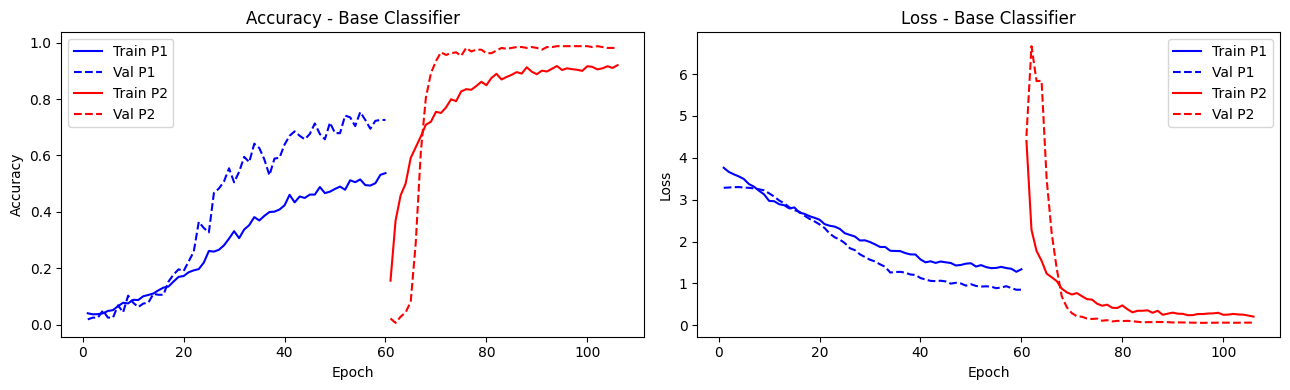

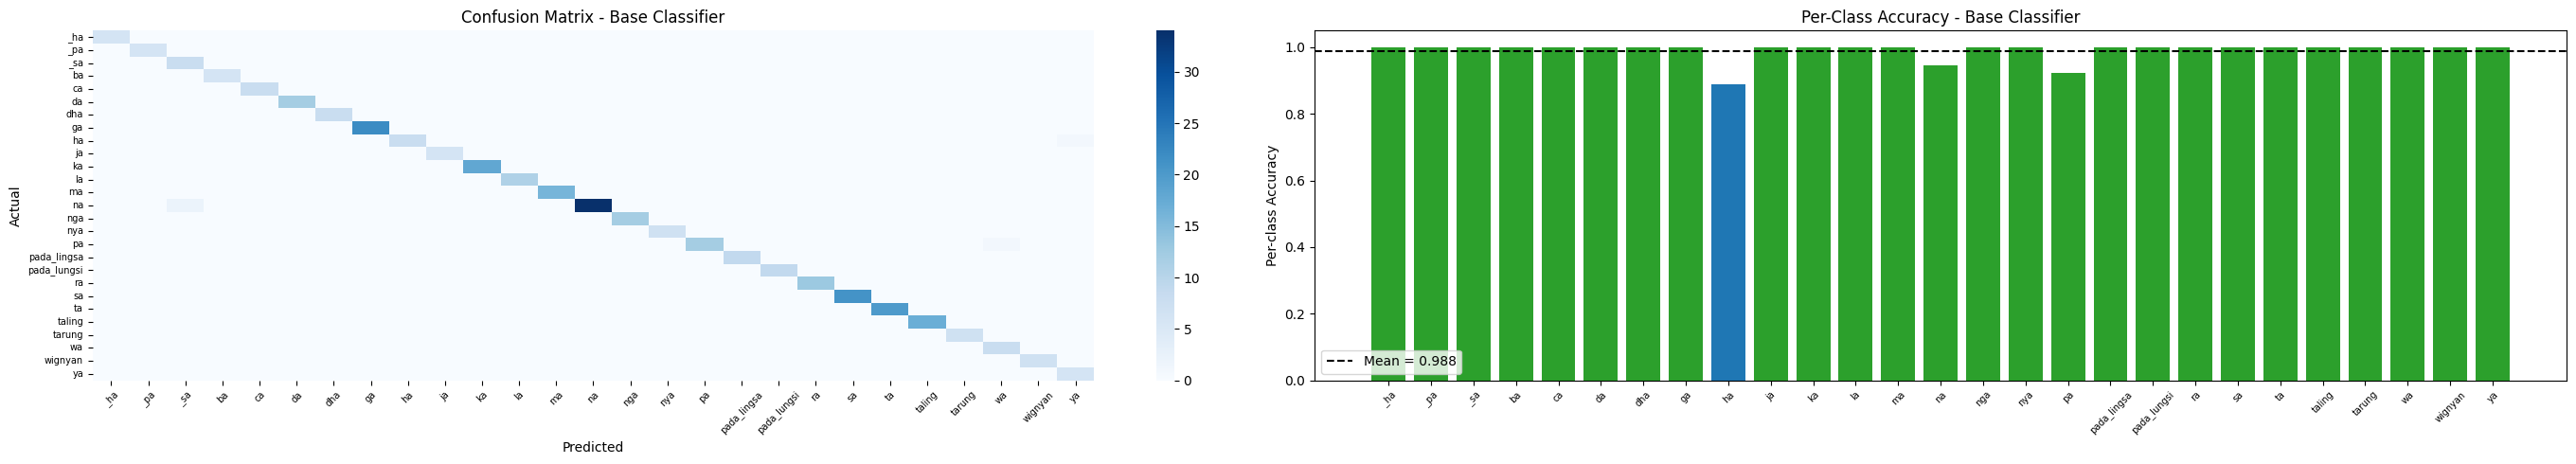

              precision    recall  f1-score   support

         _ha     1.0000    1.0000    1.0000         6
         _pa     1.0000    1.0000    1.0000         6
         _sa     0.8000    1.0000    0.8889         8
          ba     1.0000    1.0000    1.0000         6
          ca     1.0000    1.0000    1.0000         8
          da     1.0000    1.0000    1.0000        12
         dha     1.0000    1.0000    1.0000         8
          ga     1.0000    1.0000    1.0000        22
          ha     1.0000    0.8889    0.9412         9
          ja     1.0000    1.0000    1.0000         6
          ka     1.0000    1.0000    1.0000        18
          la     1.0000    1.0000    1.0000        11
          ma     1.0000    1.0000    1.0000        16
          na     1.0000    0.9444    0.9714        36
         nga     1.0000    1.0000    1.0000        12
         nya     1.0000    1.0000    1.0000         7
          pa     1.0000    0.9231    0.9600        13
 pada_lingsa     1.0000    

In [ ]:
# 2.6 - Training curves and evaluation
plot_history(h_base_p1, h_base_p2, title="Base Classifier")

best_base = keras.models.load_model(BASE_MODEL_PATH)
base_acc  = evaluate_and_plot(best_base, base_val, title="Base Classifier")

# 2.7 - Save config
base_cfg = {
    "model_path"   : BASE_MODEL_PATH,
    "img_size"     : IMG_SIZE,
    "position"     : "base",
    "min_samples"  : MIN_SAMPLES,
    "num_classes"  : base_train.num_classes,
    "class_indices": base_train.class_indices,
    "val_accuracy" : round(base_acc, 4),
}
cfg_path = os.path.join(MODEL_DIR, "stage2_base_config.json")
with open(cfg_path, "w") as f:
    json.dump(base_cfg, f, indent=2)
print(f"Base model saved  -> {BASE_MODEL_PATH}")
print(f"Config saved      -> {cfg_path}")
print(f"val_accuracy: {base_acc:.4f}")

## Section 3 - Sandhangan Classifier (Unified)

Recognises all sandhangan marks in a single model (thesis Bab III 3.6.2).
All secondary components (above, below, beside, wrapped) are classified by the same model
because each sandhangan has a visually distinct shape independent of its position.

Differences from the base classifier:
- build_sandh_generators: rotation 15, shift 0.12, zoom 0.15, shear 0.10
- FINE_TUNE_AT_SANDH=150 to limit backbone overfitting on the smaller dataset
- Label smoothing=0.1 to prevent the model collapsing onto the dominant class
- patience_es=20 to allow more epochs before early stopping

In [ ]:
# 3.0 - Skip guard
if len(sandh_classes) < 2:
    raise RuntimeError(
        f"Section 3 skipped - only {len(sandh_classes)} sandhangan class(es) meet "
        f"MIN_SAMPLES={MIN_SAMPLES}. Label more data with density_labeler.py --mode stage2.")

# 3.1 - Generators (heavier augmentation)
sandh_train, sandh_val = build_sandh_generators(SANDH_DIR, sandh_classes)
print(f"\nSandhangan classes ({sandh_train.num_classes}): {sandh_classes}")
print(f"Train samples : {sandh_train.samples}")
print(f"Val   samples : {sandh_val.samples}")

# 3.2 - Class weights
sandh_class_weights = get_class_weights(sandh_train)
print(f"\nClass weights (top-5 heaviest):")
idx_to_sandh = {v: k for k, v in sandh_train.class_indices.items()}
sorted_scw   = sorted(sandh_class_weights.items(), key=lambda x: x[1], reverse=True)
for idx, w in sorted_scw[:5]:
    print(f"  {idx_to_sandh[idx]:<22}  w={w:.3f}")

Found 1280 images belonging to 23 classes.
Found 313 images belonging to 23 classes.

Sandhangan classes (23): ['_ba', '_ca', '_da', '_dha', '_ja', '_ka', '_la', '_na', '_nga', '_ta', '_wa', '_ya', 'cecak', 'layar', 'pangkon', 'pengkal', 'pepet', 'pepet_cecak', 'pepet_layar', 'suku', 'wulu', 'wulu_cecak', 'wulu_layar']
Train samples : 1280
Val   samples : 313

Class weights (top-5 heaviest):
  _ca                     w=1.159
  _ja                     w=1.159
  _nga                    w=1.159
  _wa                     w=1.159
  _ya                     w=1.159


In [ ]:
# 3.3 - Build model
sandh_model, sandh_bb = build_efficientnet_classifier(sandh_train.num_classes)
sandh_model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy",
             keras.metrics.TopKCategoricalAccuracy(3, name="top3_acc")],
)
sandh_model.summary(line_length=90)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)            │ (None, 128, 128, 1)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                     │ (None, 128, 128, 3)          │               3 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)           │ (None, 1280)                 │       4,049,571 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization_1                 │ (None, 1280)                 │           5,120 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                   │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                       │ (None, 256)                  │         327,936 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                   │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                       │ (None, 23)                   │           5,911 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 4,388,541 (16.74 MB)

 Trainable params: 336,410 (1.28 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# 3.4 - Phase 1: train head only
sp1_path = SANDH_MODEL_PATH.replace(".keras", "_phase1.keras")
print("Phase 1 - head only, backbone frozen")
h_sandh_p1 = sandh_model.fit(
    sandh_train,
    validation_data=sandh_val,
    epochs=EPOCHS,
    class_weight=sandh_class_weights,
    callbacks=standard_callbacks(sp1_path, patience_es=20, patience_lr=7),
)
print(f"Phase 1 best val_accuracy: {max(h_sandh_p1.history['val_accuracy']):.4f}")

Phase 1 - head only, backbone frozen
Epoch 1/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.0348 - loss: 3.5235 - top3_acc: 0.1118
Epoch 1: val_accuracy improved from None to 0.03834, saving model to /content/drive/MyDrive/Dataset Skripsi/tahap2/stage2_sandhangan_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dataset Skripsi/tahap2/stage2_sandhangan_phase1.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 472s 11s/step - accuracy: 0.0383 - loss: 3.4980 - top3_acc: 0.1203 - val_accuracy: 0.0383 - val_loss: 3.1595 - val_top3_acc: 0.1182 - learning_rate: 0.0010
Epoch 2/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.0362 - loss: 3.5694 - top3_acc: 0.1347
Epoch 2: val_accuracy improved from 0.03834 to 0.04153, saving model to /content/drive/MyDrive/Dataset Skripsi/tahap2/stage2_sandhangan_phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Dataset Skripsi/tahap2/stage2_sandhangan_phase1.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - accuracy: 0

In [ ]:
# 3.5 - Phase 2: fine-tune top backbone layers
# FINE_TUNE_AT_SANDH=150 unfreezes fewer layers than the base classifier (100)
sandh_bb.trainable = True
for layer in sandh_bb.layers[:FINE_TUNE_AT_SANDH]:
    layer.trainable = False
print(f"Phase 2 - fine-tuning from backbone layer {FINE_TUNE_AT_SANDH} onward")
print(f"  Trainable layers: {sum(1 for l in sandh_model.layers if l.trainable)}")

sandh_model.compile(
    optimizer=keras.optimizers.Adam(LR_FINETUNE),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy",
             keras.metrics.TopKCategoricalAccuracy(3, name="top3_acc")],
)
h_sandh_p2 = sandh_model.fit(
    sandh_train,
    validation_data=sandh_val,
    epochs=EPOCHS,
    class_weight=sandh_class_weights,
    callbacks=standard_callbacks(SANDH_MODEL_PATH, patience_es=20, patience_lr=7),
)
print(f"Phase 2 best val_accuracy: {max(h_sandh_p2.history['val_accuracy']):.4f}")

Phase 2 - fine-tuning from backbone layer 150 onward
  Trainable layers: 8
Epoch 1/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.0984 - loss: 5.3738 - top3_acc: 0.2616
Epoch 1: val_accuracy improved from None to 0.18530, saving model to /content/drive/MyDrive/Dataset Skripsi/tahap2/stage2_sandhangan.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dataset Skripsi/tahap2/stage2_sandhangan.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 65s 568ms/step - accuracy: 0.1734 - loss: 4.4639 - top3_acc: 0.3758 - val_accuracy: 0.1853 - val_loss: 3.3460 - val_top3_acc: 0.4153 - learning_rate: 1.0000e-04
Epoch 2/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.3586 - loss: 2.9391 - top3_acc: 0.6016
Epoch 2: val_accuracy did not improve from 0.18530
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - accuracy: 0.3875 - loss: 2.8481 - top3_acc: 0.6297 - val_accuracy: 0.1597 - val_loss: 3.3950 - val_top3_acc: 0.3514 - learning_rate: 1.0000e-04
Epoch 3/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 201m

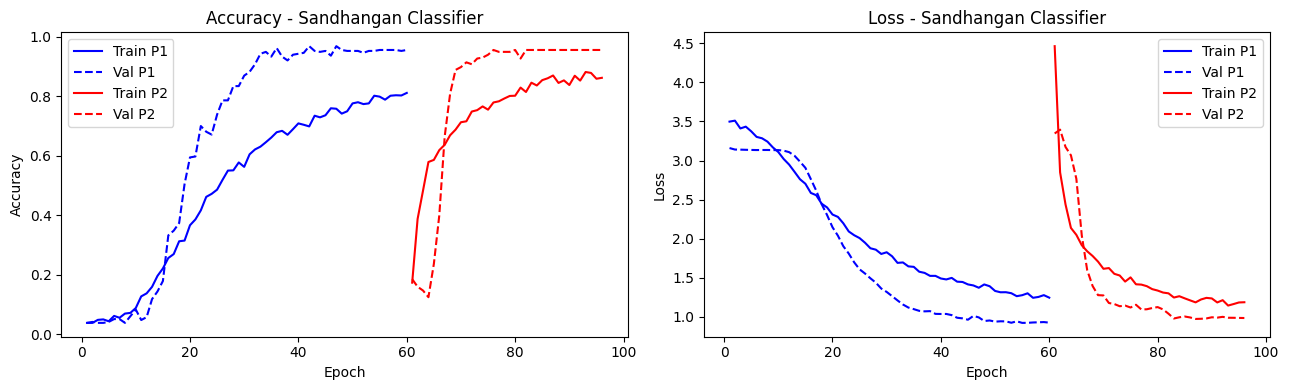

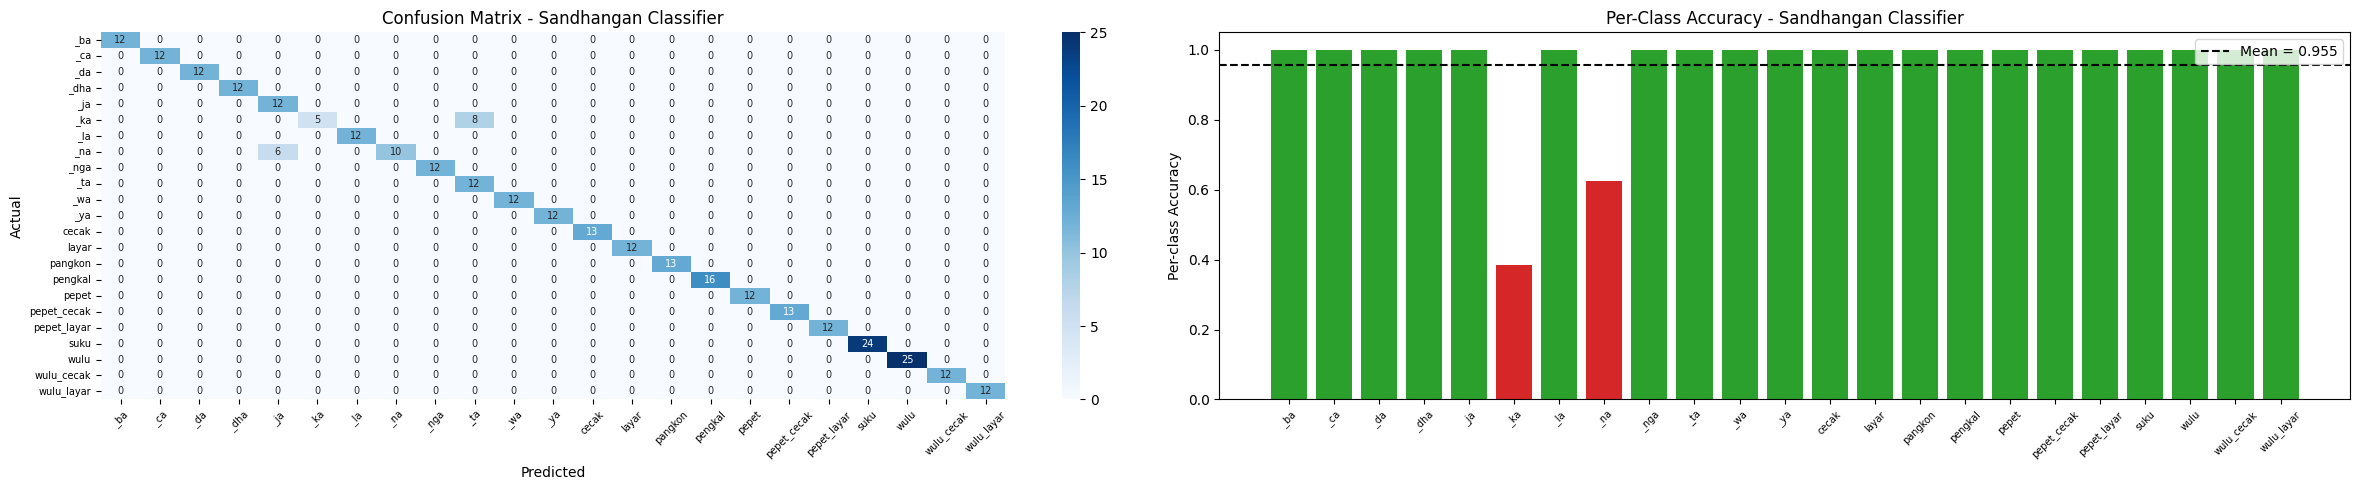

              precision    recall  f1-score   support

         _ba     1.0000    1.0000    1.0000        12
         _ca     1.0000    1.0000    1.0000        12
         _da     1.0000    1.0000    1.0000        12
        _dha     1.0000    1.0000    1.0000        12
         _ja     0.6667    1.0000    0.8000        12
         _ka     1.0000    0.3846    0.5556        13
         _la     1.0000    1.0000    1.0000        12
         _na     1.0000    0.6250    0.7692        16
        _nga     1.0000    1.0000    1.0000        12
         _ta     0.6000    1.0000    0.7500        12
         _wa     1.0000    1.0000    1.0000        12
         _ya     1.0000    1.0000    1.0000        12
       cecak     1.0000    1.0000    1.0000        13
       layar     1.0000    1.0000    1.0000        12
     pangkon     1.0000    1.0000    1.0000        13
     pengkal     1.0000    1.0000    1.0000        16
       pepet     1.0000    1.0000    1.0000        12
 pepet_cecak     1.0000    

In [ ]:
# 3.6 - Training curves and evaluation
plot_history(h_sandh_p1, h_sandh_p2, title="Sandhangan Classifier")

best_sandh = keras.models.load_model(SANDH_MODEL_PATH)
sandh_acc  = evaluate_and_plot(best_sandh, sandh_val, title="Sandhangan Classifier")

# 3.7 - Save config
sandh_cfg = {
    "model_path"   : SANDH_MODEL_PATH,
    "img_size"     : IMG_SIZE,
    "position"     : "sandhangan",
    "min_samples"  : MIN_SAMPLES,
    "num_classes"  : sandh_train.num_classes,
    "class_indices": sandh_train.class_indices,
    "val_accuracy" : round(sandh_acc, 4),
}
cfg_path = os.path.join(MODEL_DIR, "stage2_sandhangan_config.json")
with open(cfg_path, "w") as f:
    json.dump(sandh_cfg, f, indent=2)
print(f"Sandhangan model saved -> {SANDH_MODEL_PATH}")
print(f"Config saved           -> {cfg_path}")
print(f"val_accuracy: {sandh_acc:.4f}")